## 1 · Installs & Imports

In [ ]:
!pip install -q imbalanced-learn joblib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os, joblib

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, learning_curve, StratifiedKFold
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, precision_recall_fscore_support
)
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from imblearn.over_sampling import SMOTE, RandomOverSampler

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 150
plt.rcParams['font.size'] = 11

print('All imports OK \u2713')

All imports OK ✓


## 2 · Data Loading

In [ ]:
from google.colab import files
uploaded = files.upload()
csv_name = list(uploaded.keys())[0]
df_raw = pd.read_csv(csv_name)
print(f'Loaded: {csv_name}')
print(f'Shape : {df_raw.shape}')
df_raw.head()

Saving pearl_ml_dataset_final_balanced (1).csv to pearl_ml_dataset_final_balanced (1).csv
Loaded: pearl_ml_dataset_final_balanced (1).csv
Shape : (55, 35)


,Timestamp,Patient_ID,Age,Condition,Level_Played,Session_Number,Sessions_On_Current_Level,Total_Targets,Correct_Hits,Wrong_Hits,...,T7_Total_RT_s,T8_Total_RT_s,T9_Total_RT_s,T10_Total_RT_s,T11_Total_RT_s,T12_Total_RT_s,T13_Total_RT_s,T14_Total_RT_s,T15_Total_RT_s,T16_Total_RT_s
0,2026-05-22T06:52:33.935Z,PT-3258,49,Other,4,3,1,16,16,15,...,0.00,0.00,0.00,1.60,4.15,1.50,0.00,12.69,4.26,2.89
1,2026-05-22T06:51:39.593Z,PT-3258,49,Other,3,2,1,15,15,7,...,2.00,0.00,1.66,2.99,0.00,2.15,3.98,2.37,1.98,4.90
2,2026-05-22T06:50:29.247Z,PT-3258,49,Other,2,1,1,16,16,13,...,1.12,1.52,0.00,0.00,3.44,0.00,2.12,0.00,2.82,4.88
3,2026-05-22T06:46:49.405Z,PT-8591,83,Parkinson's Disease,4,6,1,16,16,13,...,4.78,0.00,8.29,1.60,1.66,0.00,0.00,8.44,0.92,1.54
4,2026-05-22T06:45:35.354Z,PT-8591,83,Parkinson's Disease,3,5,2,15,15,65,...,3.95,7.01,4.12,0.00,0.00,3.99,0.00,3.99,0.00,11.28


## 3 · Data Inspection

In [ ]:
print('=== Column Names ===')
print(list(df_raw.columns))

print('\n=== Missing Values ===')
miss = df_raw.isnull().sum()
print(miss[miss > 0] if miss.any() else 'No missing values')

print('\n=== Data Types ===')
print(df_raw.dtypes)

print('\n=== Target Distribution ===')
# Updated from 'level_recommended' to 'ML_TARGET_Next_Level' to match CSV
TARGET_COL = 'ML_TARGET_Next_Level'
assert TARGET_COL in df_raw.columns, f'ERROR: target column "{TARGET_COL}" not found in CSV!'
print(df_raw[TARGET_COL].value_counts())

print('\n=== Numeric Summary ===')
df_raw.describe().round(2)

=== Column Names ===
['Timestamp', 'Patient_ID', 'Age', 'Condition', 'Level_Played', 'Session_Number', 'Sessions_On_Current_Level', 'Total_Targets', 'Correct_Hits', 'Wrong_Hits', 'Accuracy_%', 'Accuracy_Trend', 'Session_Duration_s', 'Avg_Reaction_Time_s', 'Best_Reaction_Time_s', 'Time_Trend_s', 'Variance_RT_s', 'Fatigue_Index', 'ML_TARGET_Next_Level', 'T1_Total_RT_s', 'T2_Total_RT_s', 'T3_Total_RT_s', 'T4_Total_RT_s', 'T5_Total_RT_s', 'T6_Total_RT_s', 'T7_Total_RT_s', 'T8_Total_RT_s', 'T9_Total_RT_s', 'T10_Total_RT_s', 'T11_Total_RT_s', 'T12_Total_RT_s', 'T13_Total_RT_s', 'T14_Total_RT_s', 'T15_Total_RT_s', 'T16_Total_RT_s']

=== Missing Values ===
No missing values

=== Data Types ===
Timestamp                     object
Patient_ID                    object
Age                            int64
Condition                     object
Level_Played                   int64
Session_Number                 int64
Sessions_On_Current_Level      int64
Total_Targets                  int64
Correct_H

,Age,Level_Played,Session_Number,Sessions_On_Current_Level,Total_Targets,Correct_Hits,Wrong_Hits,Accuracy_%,Accuracy_Trend,Session_Duration_s,...,T7_Total_RT_s,T8_Total_RT_s,T9_Total_RT_s,T10_Total_RT_s,T11_Total_RT_s,T12_Total_RT_s,T13_Total_RT_s,T14_Total_RT_s,T15_Total_RT_s,T16_Total_RT_s
count,55.00,55.00,55.00,55.00,55.00,55.00,55.00,55.00,55.00,55.00,...,55.00,55.00,55.00,55.00,55.00,55.00,55.00,55.00,55.00,55.00
mean,50.73,2.38,2.58,1.69,14.18,13.44,13.62,63.58,-1.45,51.40,...,2.37,2.78,1.86,2.32,2.54,2.18,2.12,2.39,1.91,2.39
std,24.77,1.10,1.55,1.14,4.48,4.89,25.93,31.27,24.40,50.19,...,3.96,7.16,2.22,4.10,4.25,2.95,4.57,2.78,3.00,5.87
min,12.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,-100.00,5.47,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,25.00,2.00,1.00,1.00,15.00,15.00,0.00,38.00,-10.00,27.75,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.54,0.08,0.00
50%,49.00,2.00,2.00,1.00,16.00,16.00,5.00,70.00,0.00,38.64,...,0.83,0.62,1.05,1.15,0.92,0.94,0.91,1.17,0.92,0.53
75%,76.00,3.00,3.00,2.00,16.00,16.00,11.00,90.50,7.75,63.70,...,2.25,2.31,2.74,2.79,3.26,3.43,2.26,3.58,1.98,1.70
max,83.00,5.00,6.00,5.00,16.00,16.00,125.00,100.00,72.00,360.65,...,17.65,44.35,8.29,19.93,18.83,12.96,31.34,12.69,18.73,38.65


## 4 · Column Standardization

In [ ]:
# Build a rename map for known column names.

COL_MAP = {
    'Patient_ID': 'patient_id',
    'Age': 'age',
    'Condition': 'condition',
    'Level_Played': 'current_level',
    'Session_Number': 'session_number',
    'Sessions_On_Current_Level': 'sessions_on_level',
    'Total_Targets': 'total_targets',
    'Correct_Hits': 'correct_hits',
    'Wrong_Hits': 'wrong_hits',
    'Accuracy_%': 'accuracy',
    'Accuracy_Trend': 'accuracy_trend',
    'Session_Duration_s': 'session_duration',
    'Avg_Reaction_Time_s': 'avg_reaction_time',
    'Best_Reaction_Time_s': 'best_reaction_time',
    'Time_Trend_s': 'time_trend',
    'Variance_RT_s': 'variance_rt',
    'Fatigue_Index': 'fatigue_index',
    'level_recommended': 'level_recommended',
}
for i in range(1, 17):
    COL_MAP[f'T{i}_Total_RT_s'] = f't{i}_rt'

# Apply only mappings that match existing columns
rename_map = {k: v for k, v in COL_MAP.items() if k in df_raw.columns}
df = df_raw.rename(columns=rename_map).copy()

# Drop columns that should not be features
drop_cols = ['Timestamp', 'ML_TARGET_Next_Level', 'patient_id', 'Patient_ID']
df.drop(columns=[c for c in drop_cols if c in df.columns], inplace=True)

TARGET = 'level_recommended'
print(f'Columns ({len(df.columns)}): {list(df.columns)}')
print(f'Target column: {TARGET}')

Columns (32): ['age', 'condition', 'current_level', 'session_number', 'sessions_on_level', 'total_targets', 'correct_hits', 'wrong_hits', 'accuracy', 'accuracy_trend', 'session_duration', 'avg_reaction_time', 'best_reaction_time', 'time_trend', 'variance_rt', 'fatigue_index', 't1_rt', 't2_rt', 't3_rt', 't4_rt', 't5_rt', 't6_rt', 't7_rt', 't8_rt', 't9_rt', 't10_rt', 't11_rt', 't12_rt', 't13_rt', 't14_rt', 't15_rt', 't16_rt']
Target column: level_recommended


## 5 · Feature Engineering

In [ ]:
t_cols = [c for c in df.columns if c.startswith('t') and c.endswith('_rt')]

if len(t_cols) > 0:
    t_vals = df[t_cols].values

    def _nonzero_mean(row):
        nz = row[row > 0]
        return nz.mean() if len(nz) > 0 else 0.0

    def _nonzero_std(row):
        nz = row[row > 0]
        return nz.std() if len(nz) > 1 else 0.0

    def fatigue_slope(row):
        # Calculate slope of RTs over time for active tasks
        nz_idx = np.where(row > 0)[0]
        if len(nz_idx) < 2:
            return 0.0
        y = row[nz_idx]
        x = nz_idx
        return np.polyfit(x, y, 1)[0]

    def early_vs_late(row):
        # Compare average RT of first half vs second half of active tasks
        nz = row[row > 0]
        if len(nz) < 2:
            return 0.0
        mid = len(nz) // 2
        return nz[mid:].mean() - nz[:mid].mean()

    df['t_mean_rt']      = [_nonzero_mean(r) for r in t_vals]
    df['t_std_rt']       = [_nonzero_std(r) for r in t_vals]
    df['t_count_active'] = [(r > 0).sum() for r in t_vals]
    df['fatigue_slope']    = [fatigue_slope(r) for r in t_vals]
    df['early_vs_late_rt'] = [early_vs_late(r) for r in t_vals]

    print(f'Added 5 engineered features from {len(t_cols)} T-columns')
else:
    print('No T-columns found, skipping T-feature engineering')

# Session intensity (safe — measures task density)
if 'total_targets' in df.columns and 'session_duration' in df.columns:
    df['session_intensity'] = df['total_targets'] / (df['session_duration'] + 0.01)
    print('Added session_intensity')

print(f'\nFinal columns ({len(df.columns)}): {list(df.columns)}')

Added 5 engineered features from 16 T-columns
Added session_intensity

Final columns (38): ['age', 'condition', 'current_level', 'session_number', 'sessions_on_level', 'total_targets', 'correct_hits', 'wrong_hits', 'accuracy', 'accuracy_trend', 'session_duration', 'avg_reaction_time', 'best_reaction_time', 'time_trend', 'variance_rt', 'fatigue_index', 't1_rt', 't2_rt', 't3_rt', 't4_rt', 't5_rt', 't6_rt', 't7_rt', 't8_rt', 't9_rt', 't10_rt', 't11_rt', 't12_rt', 't13_rt', 't14_rt', 't15_rt', 't16_rt', 't_mean_rt', 't_std_rt', 't_count_active', 'fatigue_slope', 'early_vs_late_rt', 'session_intensity']


## 6 · Preprocessing & Train/Test Split

In [ ]:
# --- Encode categorical 'condition' column if present ---
if 'condition' in df.columns:
    df = pd.get_dummies(df, columns=['condition'], prefix='cond')
    print('One-hot encoded: condition')

# --- Separate X and y ---
# Fix: Extract target from df_raw since it was dropped from df during standardization
if 'ML_TARGET_Next_Level' in df_raw.columns:
    y_raw = df_raw['ML_TARGET_Next_Level'].copy()
else:
    # Fallback to current TARGET name if already processed
    y_raw = df[TARGET].copy() if TARGET in df.columns else df.iloc[:, -1]

# Ensure X only contains feature columns
X_df = df.drop(columns=[TARGET]) if TARGET in df.columns else df.copy()

# Keep only numeric columns as features
feature_cols = [c for c in X_df.columns if X_df[c].dtype in ['float64','int64','uint8','bool']]
X = X_df[feature_cols].values.astype(float)
X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

# --- Encode target ---
le = LabelEncoder()
y = le.fit_transform(y_raw)
print(f'\nTarget classes: {list(le.classes_)}')
for i, cls in enumerate(le.classes_):
    print(f'  {i} = {cls}')

# --- Train / Test split ---
# ADDED: stratify=y now that classes are balanced
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'\nFeatures: {len(feature_cols)}')
print(f'Train: {X_train.shape[0]} samples')
print(f'Test : {X_test.shape[0]} samples')
print(f'\nTrain distribution: {dict(zip(*np.unique(y_train, return_counts=True)))}')
print(f'Test  distribution: {dict(zip(*np.unique(y_test, return_counts=True)))}')

# --- Scale (fit on train only) ---
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)
print("\nScaling applied (fit on train only) \u2713")

One-hot encoded: condition

Target classes: ['demote', 'promote', 'stay']
  0 = demote
  1 = promote
  2 = stay

Features: 42
Train: 44 samples
Test : 11 samples

Train distribution: {np.int64(0): np.int64(8), np.int64(1): np.int64(6), np.int64(2): np.int64(30)}
Test  distribution: {np.int64(0): np.int64(2), np.int64(1): np.int64(2), np.int64(2): np.int64(7)}

Scaling applied (fit on train only) ✓


## 7 · SMOTE Augmentation (Training Data Only)

In [ ]:
print('=== Before SMOTE ===')
train_counts = dict(zip(*np.unique(y_train, return_counts=True)))
for idx, cnt in train_counts.items():
    print(f'  {le.classes_[idx]}: {cnt}')

min_count = min(train_counts.values())

try:
    k = min(3, min_count - 1) if min_count >= 4 else max(1, min_count - 1)
    if k < 1:
        raise ValueError('Not enough samples for SMOTE')
    sampler = SMOTE(k_neighbors=k, random_state=42)
    X_train_res, y_train_res = sampler.fit_resample(X_train, y_train)
    print('\nSMOTE applied \u2713')
except Exception as e:
    print(f'SMOTE failed ({e}), using RandomOverSampler')
    sampler = RandomOverSampler(random_state=42)
    X_train_res, y_train_res = sampler.fit_resample(X_train, y_train)
    print('RandomOverSampler applied \u2713')

print('\n=== After SMOTE ===')
res_counts = dict(zip(*np.unique(y_train_res, return_counts=True)))
for idx, cnt in res_counts.items():
    print(f'  {le.classes_[idx]}: {cnt}')
print(f'Total training samples: {len(y_train_res)}')

=== Before SMOTE ===
  demote: 8
  promote: 6
  stay: 30

SMOTE applied ✓

=== After SMOTE ===
  demote: 30
  promote: 30
  stay: 30
Total training samples: 90


## 8 · Model Training

In [ ]:
k_knn = min(7, max(3, int(np.sqrt(len(X_train_res)))))

models = {
    'Random Forest': RandomForestClassifier(
        n_estimators=100, max_depth=5, min_samples_leaf=3, random_state=42),
    'SVM': SVC(
        kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42),
    'KNN': KNeighborsClassifier(
        n_neighbors=k_knn, weights='distance'),
    'Decision Tree': DecisionTreeClassifier(
        max_depth=4, min_samples_leaf=3, random_state=42),
    'Naive Bayes': GaussianNB(),
}

results = {}

print('=== Training 5 Models ===')
print(f'Training on {X_train_res.shape[0]} SMOTE-expanded samples')
print(f'Testing on  {X_test.shape[0]} real clinical samples\n')

for name, model in models.items():
    model.fit(X_train_res, y_train_res)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred, average='macro', zero_division=0)
    results[name] = {'model': model, 'y_pred': y_pred, 'accuracy': acc, 'f1_macro': f1}
    print(f'  {name:20s}  Acc={acc:.3f}  F1={f1:.3f}')

print('\nAll models trained \u2713')

=== Training 5 Models ===
Training on 90 SMOTE-expanded samples
Testing on  11 real clinical samples

  Random Forest         Acc=0.818  F1=0.625
  SVM                   Acc=0.636  F1=0.472
  KNN                   Acc=0.455  F1=0.238
  Decision Tree         Acc=0.909  F1=0.867
  Naive Bayes           Acc=0.636  F1=0.571

All models trained ✓


## 9 · Evaluation — Detailed Reports

In [ ]:
from sklearn.metrics import multilabel_confusion_matrix

def compute_specificity(y_true, y_pred, labels):
    """Compute per-class specificity from the multilabel confusion matrix."""
    mcm = multilabel_confusion_matrix(y_true, y_pred, labels=labels)
    specs = []
    for cm_i in mcm:
        tn, fp = cm_i[0, 0], cm_i[0, 1]
        specs.append(tn / (tn + fp) if (tn + fp) > 0 else 0.0)
    return specs

print('=' * 70)
print('DETAILED EVALUATION ON REAL CLINICAL TEST DATA')
print('=' * 70)

all_labels = np.arange(len(le.classes_))
summary_rows = []

for name, res in results.items():
    y_pred = res['y_pred']
    acc = res['accuracy']

    p, r, f, sup = precision_recall_fscore_support(
        y_test, y_pred, average=None, labels=all_labels, zero_division=0)
    p_macro, r_macro, f_macro, _ = precision_recall_fscore_support(
        y_test, y_pred, average='macro', zero_division=0)
    specs = compute_specificity(y_test, y_pred, all_labels)

    print(f'\n{"="*15} {name} {"="*15}')

    # Per-class table
    report_df = pd.DataFrame({
        'Class': le.classes_,
        'Precision': np.round(p, 4),
        'Recall': np.round(r, 4),
        'F1-Score': np.round(f, 4),
        'Specificity': np.round(specs, 4),
        'Support': sup.astype(int),
    })
    display(report_df)

    print(f'  Accuracy    : {acc:.4f}')
    print(f'  Macro Prec  : {p_macro:.4f}')
    print(f'  Macro Recall: {r_macro:.4f}')
    print(f'  Macro F1    : {f_macro:.4f}')
    print(f'  Avg Specif. : {np.mean(specs):.4f}')

    # Suspicious accuracy warning
    if acc >= 0.98:
        print(f'  \u26a0\ufe0f WARNING: {name} accuracy is {acc:.1%} — '
              f'suspiciously high for a small clinical dataset. '
              f'Check for data leakage or overfitting!')

    summary_rows.append({
        'Model': name,
        'Accuracy': round(acc, 4),
        'Precision': round(p_macro, 4),
        'Recall': round(r_macro, 4),
        'F1 Macro': round(f_macro, 4),
        'Specificity': round(np.mean(specs), 4),
    })

summary_df = pd.DataFrame(summary_rows)
print('\n' + '=' * 70)
print('SUMMARY TABLE')
print('=' * 70)
display(summary_df.sort_values('F1 Macro', ascending=False))

DETAILED EVALUATION ON REAL CLINICAL TEST DATA

=============== Random Forest ===============


,Class,Precision,Recall,F1-Score,Specificity,Support
0,demote,1.0000,1.0,1.000,1.0,2
1,promote,0.0000,0.0,0.000,1.0,2
2,stay,0.7778,1.0,0.875,0.5,7


  Accuracy    : 0.8182
  Macro Prec  : 0.5926
  Macro Recall: 0.6667
  Macro F1    : 0.6250
  Avg Specif. : 0.8333

=============== SVM ===============


,Class,Precision,Recall,F1-Score,Specificity,Support
0,demote,1.0000,0.5000,0.6667,1.0000,2
1,promote,0.0000,0.0000,0.0000,0.8889,2
2,stay,0.6667,0.8571,0.7500,0.2500,7


  Accuracy    : 0.6364
  Macro Prec  : 0.5556
  Macro Recall: 0.4524
  Macro F1    : 0.4722
  Avg Specif. : 0.7130

=============== KNN ===============


...

,Class,Precision,Recall,F1-Score,Specificity,Support
0,demote,1.000,1.0,1.0000,1.00,2
1,promote,1.000,0.5,0.6667,1.00,2
2,stay,0.875,1.0,0.9333,0.75,7


  Accuracy    : 0.9091
  Macro Prec  : 0.9583
  Macro Recall: 0.8333
  Macro F1    : 0.8667
  Avg Specif. : 0.9167

=============== Naive Bayes ===============


,Class,Precision,Recall,F1-Score,Specificity,Support
0,demote,1.0000,1.0000,1.0000,1.0000,2
1,promote,0.0000,0.0000,0.0000,0.7778,2
2,stay,0.7143,0.7143,0.7143,0.5000,7


  Accuracy    : 0.6364
  Macro Prec  : 0.5714
  Macro Recall: 0.5714
  Macro F1    : 0.5714
  Avg Specif. : 0.7593

SUMMARY TABLE


,Model,Accuracy,Precision,Recall,F1 Macro,Specificity
3,Decision Tree,0.9091,0.9583,0.8333,0.8667,0.9167
0,Random Forest,0.8182,0.5926,0.6667,0.6250,0.8333
4,Naive Bayes,0.6364,0.5714,0.5714,0.5714,0.7593
1,SVM,0.6364,0.5556,0.4524,0.4722,0.7130
2,KNN,0.4545,0.2381,0.2381,0.2381,0.6852


## 10 · Visualizations

### 10a · Confusion Matrices (all 5 models)

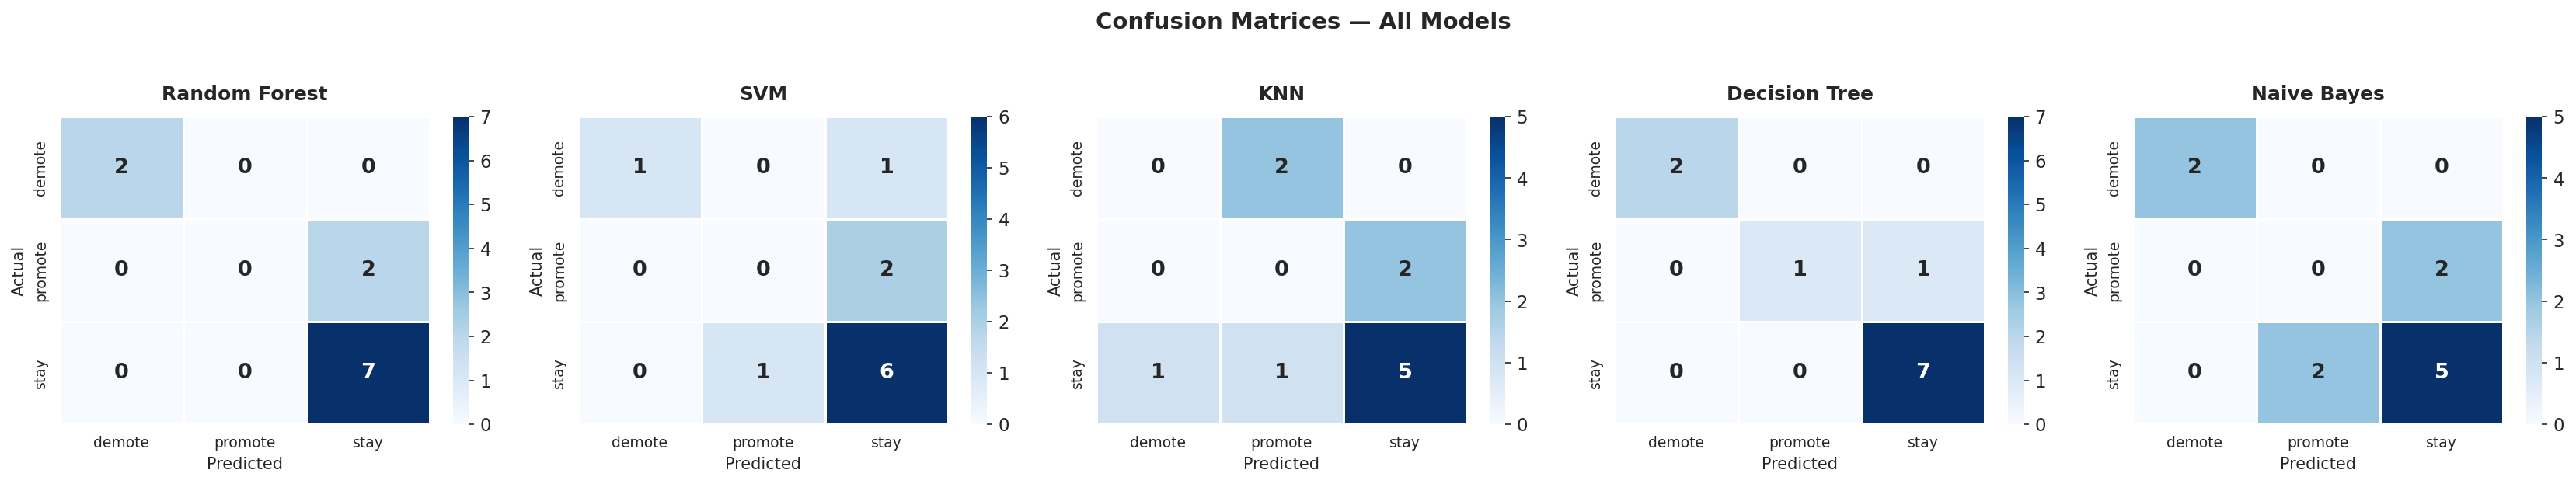

Saved: confusion_matrices.png


In [ ]:
n_models = len(results)
fig, axes = plt.subplots(1, n_models, figsize=(4.5 * n_models, 4))

if n_models == 1:
    axes = [axes]

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'], labels=all_labels)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues', ax=ax,
        xticklabels=le.classes_, yticklabels=le.classes_,
        linewidths=0.5, linecolor='white',
        annot_kws={'fontsize': 13, 'fontweight': 'bold'}
    )
    ax.set_title(name, fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel('Predicted', fontsize=10)
    ax.set_ylabel('Actual', fontsize=10)
    ax.tick_params(labelsize=9)

fig.suptitle('Confusion Matrices — All Models', fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: confusion_matrices.png')

### 10b · Model Comparison — Test Accuracy

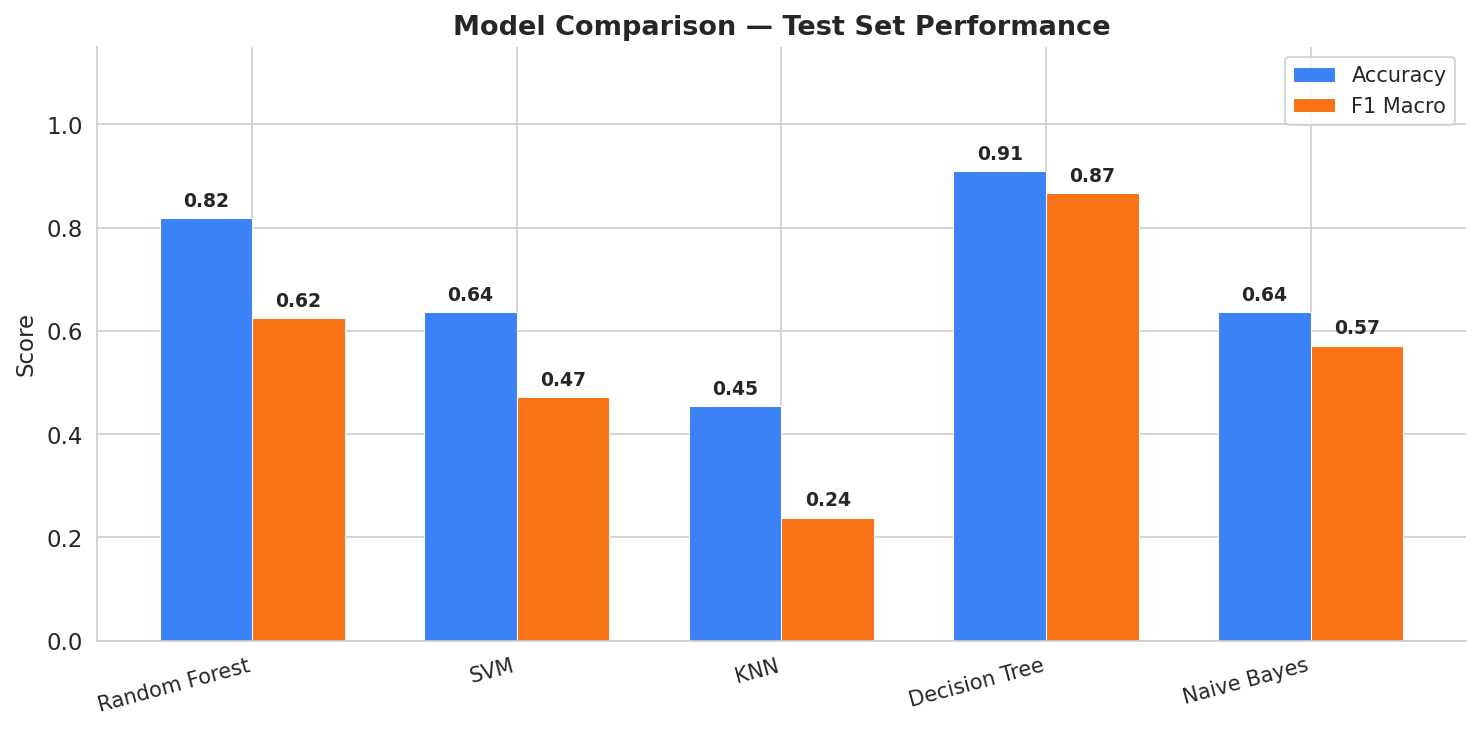

Saved: model_comparison.png


In [ ]:
model_names = list(results.keys())
accuracies  = [results[n]['accuracy'] for n in model_names]
f1_scores_  = [results[n]['f1_macro'] for n in model_names]

x = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))

bars1 = ax.bar(x - width/2, accuracies, width, label='Accuracy',
               color='#3b82f6', edgecolor='white', linewidth=0.5)
bars2 = ax.bar(x + width/2, f1_scores_, width, label='F1 Macro',
               color='#f97316', edgecolor='white', linewidth=0.5)

# Value labels on bars
for bar in bars1:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.015,
            f'{h:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
for bar in bars2:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.015,
            f'{h:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=15, ha='right', fontsize=10)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Model Comparison — Test Set Performance', fontsize=13, fontweight='bold')
ax.legend(fontsize=10, loc='upper right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: model_comparison.png')

### 10c · Best Model — Per-Class Precision / Recall / F1

Best model: Decision Tree  (F1=0.867)



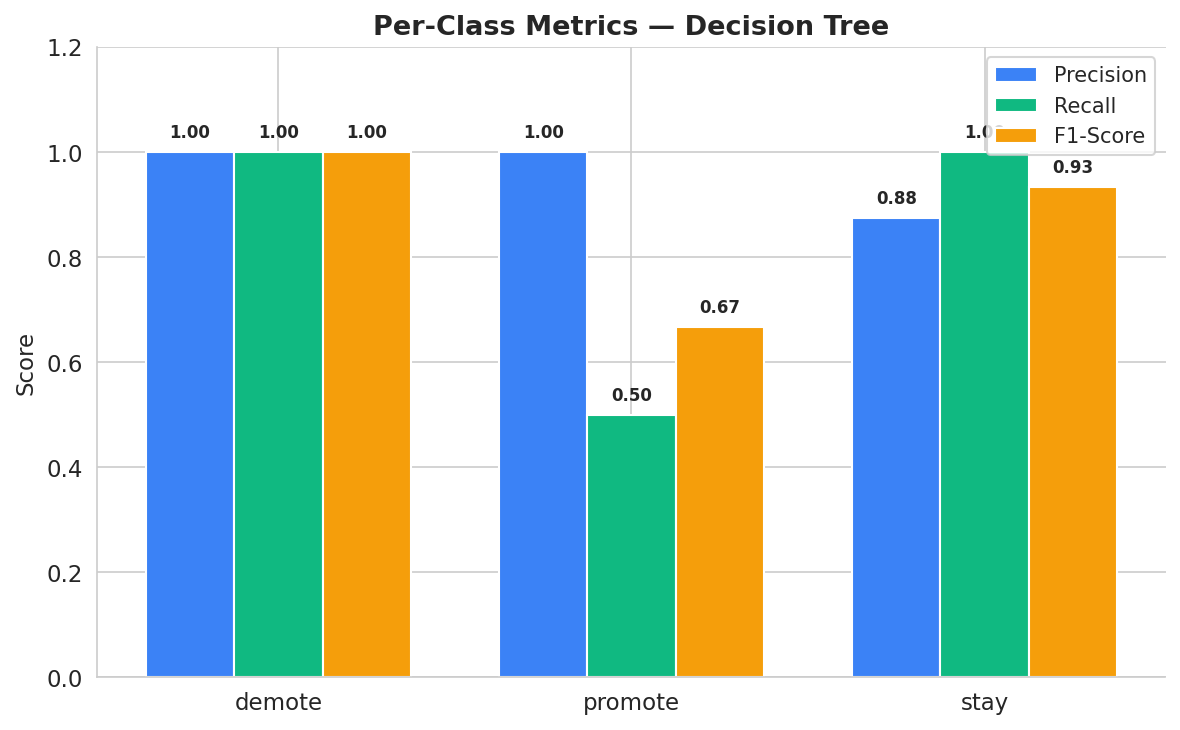

Saved: best_model_per_class.png


In [ ]:
# Identify best model by F1 Macro
best_name = max(results, key=lambda n: results[n]['f1_macro'])
best_res  = results[best_name]
print(f'Best model: {best_name}  (F1={best_res["f1_macro"]:.3f})\n')

p, r, f, sup = precision_recall_fscore_support(
    y_test, best_res['y_pred'], average=None, labels=all_labels, zero_division=0)

x = np.arange(len(le.classes_))
width = 0.25

fig, ax = plt.subplots(figsize=(8, 5))

b1 = ax.bar(x - width, p, width, label='Precision', color='#3b82f6', edgecolor='white')
b2 = ax.bar(x,         r, width, label='Recall',    color='#10b981', edgecolor='white')
b3 = ax.bar(x + width, f, width, label='F1-Score',  color='#f59e0b', edgecolor='white')

for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.02,
                f'{h:.2f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(le.classes_, fontsize=11)
ax.set_ylim(0, 1.2)
ax.set_ylabel('Score', fontsize=11)
ax.set_title(f'Per-Class Metrics — {best_name}', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('best_model_per_class.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: best_model_per_class.png')

### 10d · Learning Curve — Best Model

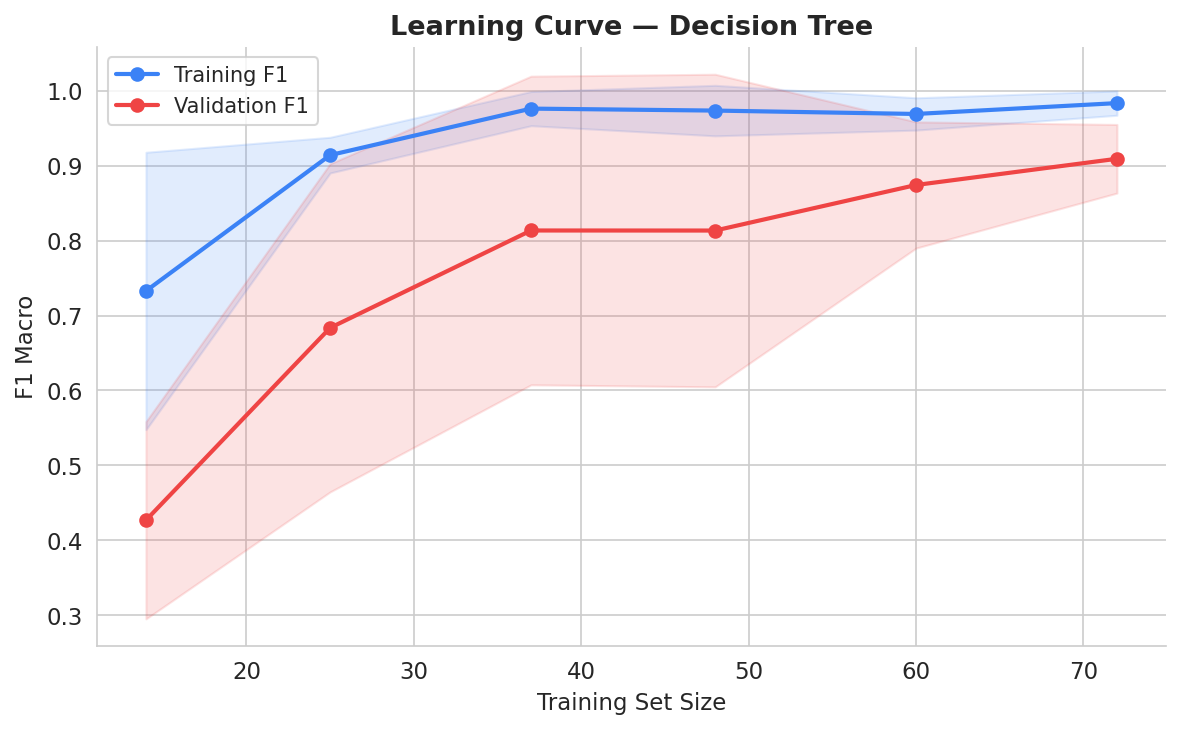

Saved: learning_curve.png


In [ ]:
best_model_obj = best_res['model']

min_class_count = min(np.bincount(y_train_res))
cv_folds = min(5, min_class_count) if min_class_count >= 2 else 2

try:
    train_sizes, train_scores, val_scores = learning_curve(
        best_model_obj, X_train_res, y_train_res,
        cv=cv_folds, scoring='f1_macro', n_jobs=-1,
        train_sizes=np.linspace(0.2, 1.0, 6),
        random_state=42
    )

    fig, ax = plt.subplots(figsize=(8, 5))

    train_mean = train_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)
    val_mean   = val_scores.mean(axis=1)
    val_std    = val_scores.std(axis=1)

    ax.plot(train_sizes, train_mean, 'o-', color='#3b82f6', label='Training F1', linewidth=2)
    ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                    alpha=0.15, color='#3b82f6')

    ax.plot(train_sizes, val_mean, 'o-', color='#ef4444', label='Validation F1', linewidth=2)
    ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std,
                    alpha=0.15, color='#ef4444')

    ax.set_xlabel('Training Set Size', fontsize=11)
    ax.set_ylabel('F1 Macro', fontsize=11)
    ax.set_title(f'Learning Curve — {best_name}', fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.savefig('learning_curve.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: learning_curve.png')

except Exception as e:
    print(f'Learning curve skipped: {e}')

## 11 · Best Model Selection

In [ ]:
print('=' * 60)
print('BEST MODEL SELECTION')
print('=' * 60)

ranking = sorted(results.items(), key=lambda x: x[1]['f1_macro'], reverse=True)

for i, (name, res) in enumerate(ranking, 1):
    marker = '\u2605' if i == 1 else ' '
    print(f'  {marker} #{i}  {name:20s}  Acc={res["accuracy"]:.4f}  F1={res["f1_macro"]:.4f}')

best_name = ranking[0][0]
best_info = ranking[0][1]

print(f'\n  Selected: {best_name}')
print(f'  Accuracy : {best_info["accuracy"]:.4f}')
print(f'  F1 Macro : {best_info["f1_macro"]:.4f}')

# Final suspicious-accuracy check
if best_info['accuracy'] >= 0.98:
    print(f'\n  \u26a0\ufe0f WARNING: Best model accuracy is {best_info["accuracy"]:.1%}.')
    print('  This is suspiciously high for a small clinical dataset.')
    print('  Please verify there is no data leakage or label contamination.')

BEST MODEL SELECTION
  ★ #1  Decision Tree         Acc=0.9091  F1=0.8667
    #2  Random Forest         Acc=0.8182  F1=0.6250
    #3  Naive Bayes           Acc=0.6364  F1=0.5714
    #4  SVM                   Acc=0.6364  F1=0.4722
    #5  KNN                   Acc=0.4545  F1=0.2381

  Selected: Decision Tree
  Accuracy : 0.9091
  F1 Macro : 0.8667


## 12 · Export Artifacts

In [ ]:
best_model_final = results[best_name]['model']

# Save model artifacts
joblib.dump(best_model_final, 'pearl_best_model.pkl')
joblib.dump(scaler,           'pearl_scaler.pkl')
joblib.dump(le,               'pearl_label_encoder.pkl')
joblib.dump(feature_cols,     'pearl_feature_columns.pkl')

# File list
export_files = [
    'pearl_best_model.pkl',
    'pearl_scaler.pkl',
    'pearl_label_encoder.pkl',
    'pearl_feature_columns.pkl',
    'confusion_matrices.png',
    'model_comparison.png',
    'best_model_per_class.png',
]
if os.path.exists('learning_curve.png'):
    export_files.append('learning_curve.png')

print('=== Saved Artifacts ===')
for f in export_files:
    if os.path.exists(f):
        sz = os.path.getsize(f) / 1024
        print(f'  \u2713 {f} ({sz:.1f} KB)')
    else:
        print(f'  \u2717 {f} (not found)')

# Auto-download all
from google.colab import files as colab_files
for f in export_files:
    if os.path.exists(f):
        colab_files.download(f)

print('\n\U0001f389 PEARL ML Pipeline Complete!')

=== Saved Artifacts ===
  ✓ pearl_best_model.pkl (2.1 KB)
  ✓ pearl_scaler.pkl (1.6 KB)
  ✓ pearl_label_encoder.pkl (0.5 KB)
  ✓ pearl_feature_columns.pkl (0.6 KB)
  ✓ confusion_matrices.png (71.7 KB)
  ✓ model_comparison.png (60.2 KB)
  ✓ best_model_per_class.png (38.8 KB)
  ✓ learning_curve.png (79.5 KB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


🎉 PEARL ML Pipeline Complete!
